# Isolation Forest para datos de generación eólica

Notebook para entrenar un modelo `IsolationForest` con datos de aerogenerador. El objetivo es detectar registros anómalos en variables como velocidad del viento, potencia generada, RPM, temperaturas, vibraciones y códigos de estado.

El modelo no predice una variable objetivo. Aprende el comportamiento normal de los datos y marca como anomalía los registros que se alejan de ese comportamiento.


In [ ]:
!pip install openpyxl joblib -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from google.colab import files
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline


## 1. Subir archivo

Admite `.xlsx`, `.xls` o `.csv`.


In [ ]:
uploaded = files.upload()

nombre_archivo = list(uploaded.keys())[0]
print("Archivo cargado:", nombre_archivo)


Saving MinAna_filtrado.xlsx to MinAna_filtrado.xlsx
Archivo cargado: MinAna_filtrado.xlsx


## 2. Cargar datos


In [ ]:
if nombre_archivo.lower().endswith((".xlsx", ".xls")):
    df = pd.read_excel(nombre_archivo)
elif nombre_archivo.lower().endswith(".csv"):
    df = pd.read_csv(nombre_archivo)
else:
    raise ValueError("Formato no soportado. Usa Excel o CSV.")

df.columns = df.columns.str.strip()

print("Filas originales:", len(df))
print("Columnas detectadas:")
print(df.columns.tolist())

df.head()


Filas originales: 432
Columnas detectadas:
['SystemNumber', 'Date', 'Time', 'TimeOffset', 'P_ACT', 'TD', 'PF', 'Q', 'U_A_N', 'U_B_N', 'U_C_N', 'I_A', 'I_B', 'I_C', 'N_GEN_CCU', 'N_ROT_PLC', 'BL1_ACT', 'V_WIN', 'POS_NAC', 'REV_NAC', 'N_GEN_PLC', 'WIND_DEV_1SEC', 'BL2_ACT', 'BL3_ACT', 'BL1_SET_V', 'BL2_SET_V', 'BL3_SET_V', 'PF_SET_V', 'N_SET1', 'N_SET2', 'M_ACT', 'M_SET', 'OS', 'STATE_FAULT', 'WIND_DEV_10SEC', 'T_GEN_1', 'T_GEN_2', 'T_BEAR_A', 'T_BEAR_B', 'T_GEAR', 'T_AMB', 'T_NAC', 'T_GEN_COOL', 'T_GEAR_BEAR', 'T_BEAR_SHAFT', 'TSR', 'RESERVE1', 'PART_COUNT', 'CBCI', 'A_TOWER', 'A_DT', 'T_GEAR_BEAR_B', 'T_TRAFO1', 'T_TRAFO2', 'T_TRAFO3', 'RESERVE3', 'RESERVE4', 'T_ExtOilHeat', 'VAC_EXT_OIL_HEAT', 'HYD_PRES', 'SCOPE1', 'SCOPE2', 'SCOPE3', 'SCOPE4', 'DI1_MAIN', 'RESERVE8', 'DI1_TOP', 'DI2_TOP', 'RESERVE9', 'RESERVE10', 'DO1_MAIN', 'RESERVE11', 'DO1_TOP', 'DO2_TOP', 'Index', 'Timestamp']


,SystemNumber,Date,Time,TimeOffset,P_ACT,TD,PF,Q,U_A_N,U_B_N,...,DI1_TOP,DI2_TOP,RESERVE9,RESERVE10,DO1_MAIN,RESERVE11,DO1_TOP,DO2_TOP,Index,Timestamp
0,15401272,06/04/2026,12:30:00,60,"262,39",2450,"-0,99","-6,11","400,6","402,91",...,-33266556,12574,0,99079,4484,0,1328034,8,NaN,06/04/2026 12:30
1,15401272,06/04/2026,12:40:00,60,"344,93",2450,1,"-4,97","401,98","404,05",...,-33266554,12574,0,99079,4484,0,1328034,8,NaN,06/04/2026 12:40
2,15401272,06/04/2026,12:50:00,60,"351,47",2450,1,"-4,8","401,99","404,33",...,-33266682,12575,0,66311,4484,0,1328034,8,NaN,06/04/2026 12:50
3,15401272,06/04/2026,13:00:00,60,"473,52",2450,"0,99","-3,68","403,25","405,51",...,-33266553,12575,0,99079,4484,0,1328034,8,NaN,06/04/2026 13:00
4,15401272,06/04/2026,13:30:00,60,"334,2",2450,1,"-4,02","399,39","401,71",...,-33266684,12575,0,66311,4484,0,1328032,8,NaN,06/04/2026 13:30


## 3. Configuración de columnas

Ajusta los nombres si tu archivo usa otros. Si alguna columna no existe, se ignorará automáticamente.


In [ ]:
columnas_candidatas = [
    "V_WIN",
    "P_ACT",
    "V_Fase_A",
    "V_Fase_B",
    "V_Fase_C",
    "Potencia_kW",
    "RPM",
    "Viento_ms",
    "T_Exterior",
    "generator_cooling_air",
    "gearbox_bearing_a",
    "rotor_bearing",
    "T_Gearbox_Brg",
    "T_Gen_Bearing_A",
    "T_Bearing_B",
    "tower_accel",
    "drive_train_accel",
    "T_Rotor_Brg",
    "Cod_Error_Principal",
    "Cod_Sistema",
    "Cod_Error"
]

features = [c for c in columnas_candidatas if c in df.columns]

if len(features) < 2:
    raise ValueError("No hay suficientes columnas válidas para entrenar Isolation Forest.")

print("Columnas usadas por el modelo:")
print(features)


Columnas usadas por el modelo:
['V_WIN', 'P_ACT']


## 4. Limpieza numérica


In [ ]:
def convertir_numero(valor):
    if pd.isna(valor):
        return np.nan
    if isinstance(valor, str):
        valor = valor.strip().replace(",", ".").replace(" ", "")
        if valor == "" or valor.lower() in ["nan", "none", "null"]:
            return np.nan
    try:
        return float(valor)
    except Exception:
        return np.nan

for col in features:
    df[col] = df[col].apply(convertir_numero)

df_modelo = df[features].copy()

print("Nulos por columna antes de limpiar:")
print(df_modelo.isna().sum())


Nulos por columna antes de limpiar:
V_WIN    0
P_ACT    0
dtype: int64


## 5. Filtros físicos básicos

Estos filtros eliminan registros claramente imposibles. Modifícalos si tu instalación trabaja con otros rangos.


In [ ]:
df_modelo = df_modelo.dropna().copy()

if "V_WIN" in df_modelo.columns:
    df_modelo = df_modelo[(df_modelo["V_WIN"] >= 0) & (df_modelo["V_WIN"] <= 35)]

if "Viento_ms" in df_modelo.columns:
    df_modelo = df_modelo[(df_modelo["Viento_ms"] >= 0) & (df_modelo["Viento_ms"] <= 35)]

for col in ["P_ACT", "Potencia_kW"]:
    if col in df_modelo.columns:
        df_modelo = df_modelo[df_modelo[col] >= 0]

if "RPM" in df_modelo.columns:
    df_modelo = df_modelo[df_modelo["RPM"] >= 0]

print("Filas válidas para entrenamiento:", len(df_modelo))

if len(df_modelo) < 50:
    raise ValueError("Hay pocas filas válidas. Revisa el archivo o relaja los filtros.")

df_modelo.describe()


Filas válidas para entrenamiento: 432


,V_WIN,P_ACT
count,432.000000,432.000000
mean,6.851389,397.160509
std,2.173947,276.862196
min,2.870000,14.940000
25%,5.000000,149.727500
50%,7.155000,359.970000
75%,8.502500,574.332500
max,12.400000,1333.170000


## 6. Entrenamiento del modelo Isolation Forest

`contamination` indica la proporción esperada de anomalías. Un valor inicial razonable suele estar entre `0.01` y `0.05`.


In [ ]:
contaminacion = 0.03

modelo = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("isolation_forest", IsolationForest(
        n_estimators=300,
        contamination=contaminacion,
        random_state=42,
        n_jobs=-1
    ))
])

modelo.fit(df_modelo[features])

predicciones = modelo.predict(df_modelo[features])
scores = modelo.decision_function(df_modelo[features])

resultado = df.loc[df_modelo.index].copy()
resultado["anomaly_score"] = scores
resultado["anomaly_label"] = np.where(predicciones == -1, "Anomalia", "Normal")
resultado["es_anomalia"] = np.where(predicciones == -1, 1, 0)

print("Registros normales:", (resultado["es_anomalia"] == 0).sum())
print("Registros anómalos:", (resultado["es_anomalia"] == 1).sum())
print("Porcentaje anomalías:", round(resultado["es_anomalia"].mean() * 100, 2), "%")

resultado.head()


Registros normales: 419
Registros anómalos: 13
Porcentaje anomalías: 3.01 %


,SystemNumber,Date,Time,TimeOffset,P_ACT,TD,PF,Q,U_A_N,U_B_N,...,RESERVE10,DO1_MAIN,RESERVE11,DO1_TOP,DO2_TOP,Index,Timestamp,anomaly_score,anomaly_label,es_anomalia
0,15401272,06/04/2026,12:30:00,60,262.39,2450,"-0,99","-6,11","400,6","402,91",...,99079,4484,0,1328034,8,NaN,06/04/2026 12:30,0.132210,Normal,0
1,15401272,06/04/2026,12:40:00,60,344.93,2450,1,"-4,97","401,98","404,05",...,99079,4484,0,1328034,8,NaN,06/04/2026 12:40,0.152815,Normal,0
2,15401272,06/04/2026,12:50:00,60,351.47,2450,1,"-4,8","401,99","404,33",...,66311,4484,0,1328034,8,NaN,06/04/2026 12:50,0.157106,Normal,0
3,15401272,06/04/2026,13:00:00,60,473.52,2450,"0,99","-3,68","403,25","405,51",...,99079,4484,0,1328034,8,NaN,06/04/2026 13:00,0.146571,Normal,0
4,15401272,06/04/2026,13:30:00,60,334.20,2450,1,"-4,02","399,39","401,71",...,66311,4484,0,1328032,8,NaN,06/04/2026 13:30,0.149550,Normal,0


## 7. Registros anómalos detectados


In [ ]:
anomalias = resultado[resultado["es_anomalia"] == 1].copy()
anomalias = anomalias.sort_values("anomaly_score")

print("Anomalías detectadas:", len(anomalias))
anomalias.head(20)


Anomalías detectadas: 13


,SystemNumber,Date,Time,TimeOffset,P_ACT,TD,PF,Q,U_A_N,U_B_N,...,RESERVE10,DO1_MAIN,RESERVE11,DO1_TOP,DO2_TOP,Index,Timestamp,anomaly_score,anomaly_label,es_anomalia
391,15401272,14/04/2026,8:10:00,60,1333.17,2450,1,"-8,37","403,03","405,56",...,99079,4484,0,1311650,8,NaN,14/04/2026 8:10,-0.188513,Anomalia,1
400,15401272,14/04/2026,11:40:00,60,1187.88,2450,1,"-10,48","401,31","403,95",...,66311,4484,0,1312674,8,NaN,14/04/2026 11:40,-0.137257,Anomalia,1
401,15401272,14/04/2026,11:50:00,60,1139.41,2450,1,"-11,04","399,96","402,65",...,66311,4484,0,1312674,8,NaN,14/04/2026 11:50,-0.083220,Anomalia,1
164,15401272,09/04/2026,12:40:00,60,1115.84,2450,1,"-11,85","403,92","406,93",...,66311,4484,0,1312674,8,NaN,09/04/2026 12:40,-0.079097,Anomalia,1
399,15401272,14/04/2026,11:30:00,60,1122.77,2450,1,"-11,07","399,19","401,98",...,66311,4484,0,1312674,8,NaN,14/04/2026 11:30,-0.078048,Anomalia,1
87,15401272,08/04/2026,9:40:00,60,1144.89,2450,1,"-7,8","404,41","408,4",...,99079,4484,0,1311650,8,NaN,08/04/2026 9:40,-0.075581,Anomalia,1
183,15401272,09/04/2026,17:40:00,60,1126.53,2450,1,"-12,05","407,29","410,09",...,99079,4484,0,1312674,8,NaN,09/04/2026 17:40,-0.068502,Anomalia,1
330,15401272,12/04/2026,17:00:00,60,14.94,2450,"-0,99","-0,31","397,99","398,01",...,99079,4484,0,1311650,8,NaN,12/04/2026 17:00,-0.038264,Anomalia,1
313,15401272,12/04/2026,12:50:00,60,16.10,2450,"-0,99","-0,32","399,45","400,32",...,99079,4484,0,1311650,8,NaN,12/04/2026 12:50,-0.031350,Anomalia,1
78,15401272,07/04/2026,21:10:00,60,26.86,2450,"0,99","-1,98","397,78","401,69",...,99079,4484,0,1311648,8,NaN,07/04/2026 21:10,-0.006802,Anomalia,1


## 8. Visualización principal

Si el dataset contiene velocidad de viento y potencia, se genera una gráfica de dispersión diferenciando registros normales y anómalos.


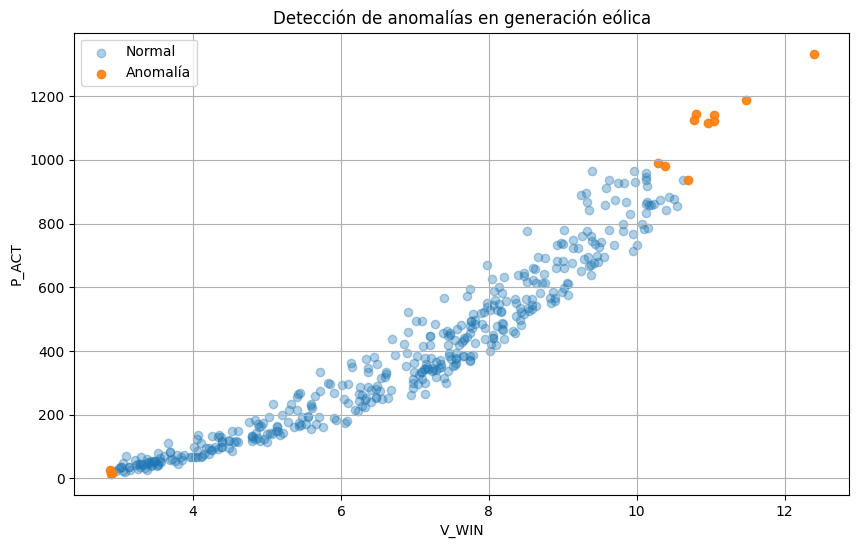

In [ ]:
def primera_columna_existente(posibles):
    for col in posibles:
        if col in resultado.columns:
            return col
    return None

col_viento = primera_columna_existente(["V_WIN", "Viento_ms"])
col_potencia = primera_columna_existente(["P_ACT", "Potencia_kW"])

if col_viento and col_potencia:
    normales = resultado[resultado["es_anomalia"] == 0]
    anom = resultado[resultado["es_anomalia"] == 1]

    plt.figure(figsize=(10, 6))
    plt.scatter(normales[col_viento], normales[col_potencia], alpha=0.35, label="Normal")
    plt.scatter(anom[col_viento], anom[col_potencia], alpha=0.9, label="Anomalía")
    plt.xlabel(col_viento)
    plt.ylabel(col_potencia)
    plt.title("Detección de anomalías en generación eólica")
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("No se han encontrado columnas de viento y potencia para esta gráfica.")


## 9. Evolución temporal de anomalías

Si existe una columna temporal, se utiliza como eje X. Si no, se usa el índice del registro.


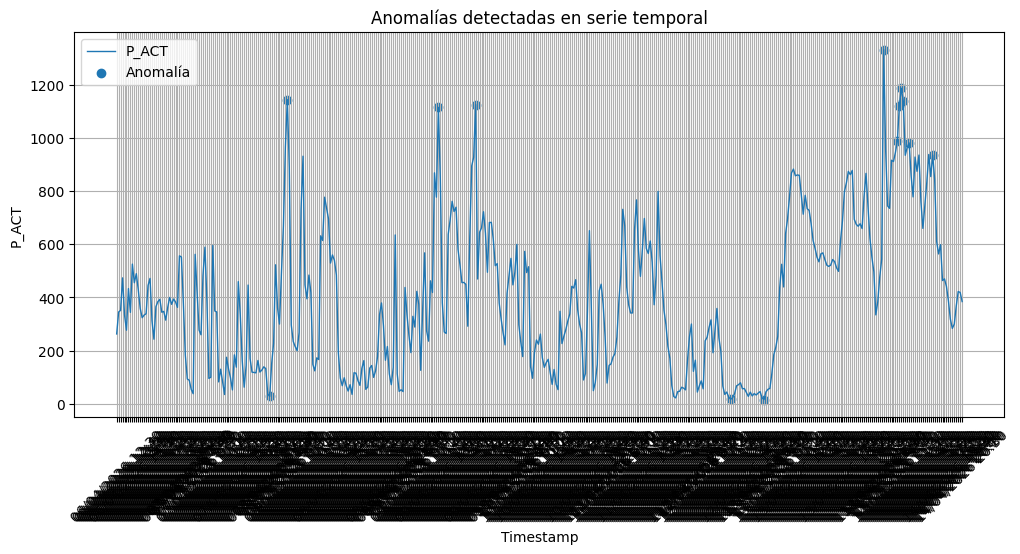

In [ ]:
col_tiempo = primera_columna_existente(["Hora", "Fecha", "Datetime", "timestamp", "Timestamp", "time", "Time"])

eje_x = resultado[col_tiempo] if col_tiempo else resultado.index

y_col = col_potencia if col_potencia else features[0]

plt.figure(figsize=(12, 5))
plt.plot(eje_x, resultado[y_col], linewidth=1, label=y_col)
plt.scatter(
    eje_x[resultado["es_anomalia"] == 1],
    resultado.loc[resultado["es_anomalia"] == 1, y_col],
    label="Anomalía"
)
plt.xlabel(col_tiempo if col_tiempo else "Índice")
plt.ylabel(y_col)
plt.title("Anomalías detectadas en serie temporal")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.show()


## 10. Distribución del score de anomalía

Cuanto menor es el score, más anómalo se considera el registro.


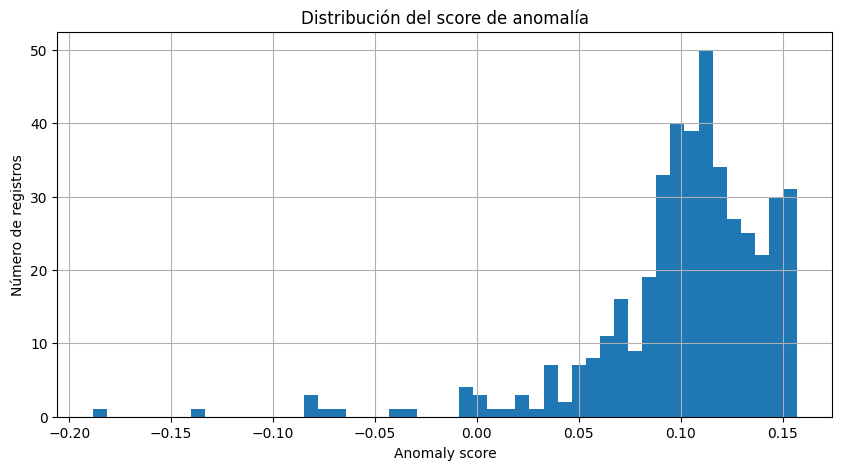

In [ ]:
plt.figure(figsize=(10, 5))
plt.hist(resultado["anomaly_score"], bins=50)
plt.xlabel("Anomaly score")
plt.ylabel("Número de registros")
plt.title("Distribución del score de anomalía")
plt.grid(True)
plt.show()


## 11. Guardar modelo y resultados


In [ ]:
resultado.to_excel("resultado_isolation_forest.xlsx", index=False)
anomalias.to_excel("anomalias_detectadas.xlsx", index=False)

joblib.dump(modelo, "modelo_isolation_forest_eolica.pkl")
joblib.dump(features, "features_isolation_forest.pkl")

print("Archivos guardados:")
print("modelo_isolation_forest_eolica.pkl")
print("features_isolation_forest.pkl")
print("resultado_isolation_forest.xlsx")
print("anomalias_detectadas.xlsx")


Archivos guardados:
modelo_isolation_forest_eolica.pkl
features_isolation_forest.pkl
resultado_isolation_forest.xlsx
anomalias_detectadas.xlsx


Umbral inferior V_WIN: 3.05
Umbral superior V_WIN: 10.5766

Distribución de Anomalia_Real:
Anomalia_Real
0    415
1     17
Name: count, dtype: int64


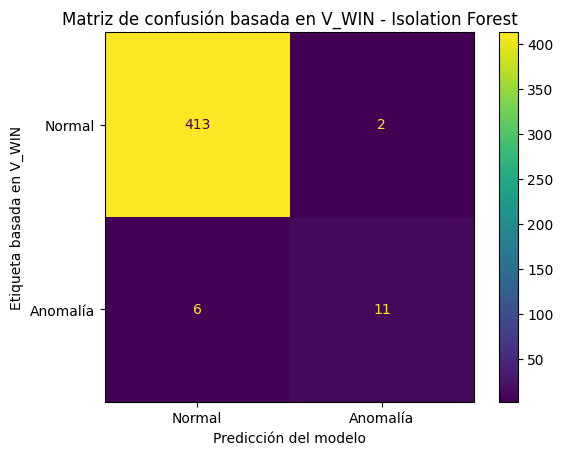

Resultados de la matriz de confusión
------------------------------------
Verdaderos negativos: 413
Falsos positivos:     2
Falsos negativos:     6
Verdaderos positivos: 11

Informe de clasificación
------------------------
              precision    recall  f1-score   support

      Normal       0.99      1.00      0.99       415
    Anomalía       0.85      0.65      0.73        17

    accuracy                           0.98       432
   macro avg       0.92      0.82      0.86       432
weighted avg       0.98      0.98      0.98       432



In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
import pandas as pd

df_eval = resultado.copy()

# Predicción del Isolation Forest
# es_anomalia: True/1 = anomalía detectada, False/0 = normal
y_pred = df_eval["es_anomalia"].astype(int)

# Etiqueta real aproximada basada solo en V_WIN
# Se consideran anomalías los valores extremos de viento
q_bajo = df_eval["V_WIN"].quantile(0.02)
q_alto = df_eval["V_WIN"].quantile(0.98)

df_eval["Anomalia_Real"] = (
    (df_eval["V_WIN"] < q_bajo) |
    (df_eval["V_WIN"] > q_alto)
).astype(int)

print("Umbral inferior V_WIN:", q_bajo)
print("Umbral superior V_WIN:", q_alto)

print("\nDistribución de Anomalia_Real:")
print(df_eval["Anomalia_Real"].value_counts())

# Matriz de confusión
cm = confusion_matrix(df_eval["Anomalia_Real"], y_pred, labels=[0, 1])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "Anomalía"]
)

disp.plot(values_format="d")
plt.title("Matriz de confusión basada en V_WIN - Isolation Forest")
plt.xlabel("Predicción del modelo")
plt.ylabel("Etiqueta basada en V_WIN")
plt.show()

tn, fp, fn, tp = cm.ravel()

print("Resultados de la matriz de confusión")
print("------------------------------------")
print(f"Verdaderos negativos: {tn}")
print(f"Falsos positivos:     {fp}")
print(f"Falsos negativos:     {fn}")
print(f"Verdaderos positivos: {tp}")

print("\nInforme de clasificación")
print("------------------------")
print(classification_report(
    df_eval["Anomalia_Real"],
    y_pred,
    target_names=["Normal", "Anomalía"],
    zero_division=0
))

## 12. Descargar archivos


In [ ]:
files.download("modelo_isolation_forest_eolica.pkl")
files.download("features_isolation_forest.pkl")
files.download("resultado_isolation_forest.xlsx")
files.download("anomalias_detectadas.xlsx")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 13. Uso posterior del modelo

El modelo guardado puede cargarse en otro script para clasificar nuevas lecturas como normales o anómalas.


In [ ]:
# Ejemplo de carga posterior
# modelo = joblib.load("modelo_isolation_forest_eolica.pkl")
# features = joblib.load("features_isolation_forest.pkl")
# pred = modelo.predict(nuevos_datos[features])
# -1 = anomalía, 1 = normal
